In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import pool
from sklearn.model_selection import train_test_split
from torch_geometric.data import Data, DataLoader
import torch_geometric.transforms as T

import combined_models

import os
import gzip
from scipy import io
import pickle

In [2]:
from torch_geometric.explain import Explainer, GNNExplainer, AttentionExplainer, PGExplainer
from torch_geometric.utils import remove_self_loops, to_undirected
from tqdm import tqdm

In [3]:
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

In [4]:
device

device(type='cuda', index=1)

# classification model

In [5]:
class Classification(nn.Module):

    def __init__(self, encoder_parameter, pooling_parameter, classifier_parameter):
        super(Classification, self).__init__()
        self.encoder = combined_models.GATEncoder(encoder_parameter[0], encoder_parameter[1], encoder_parameter[2], encoder_parameter[3])
        self.pooling = combined_models.GATPooling(pooling_parameter[0], pooling_parameter[1], pooling_parameter[2])
        self.classifier = combined_models.Classifier(classifier_parameter[0], classifier_parameter[1], classifier_parameter[2])
    
    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.encoder(x, edge_index)
        x = self.pooling(x, edge_index, batch)
        x = self.classifier(x)
        return x

class ClassificationSimplifiedPooling(nn.Module):

    def __init__(self, encoder_parameter, classifier_parameter):
        super(ClassificationSimplifiedPooling, self).__init__()
        self.encoder = combined_models.GATEncoder(encoder_parameter[0], encoder_parameter[1], encoder_parameter[2], encoder_parameter[3])
        self.classifier = combined_models.Classifier(classifier_parameter[0], classifier_parameter[1], classifier_parameter[2])
    
    def forward(self, x, edge_index, batch):
        # x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.encoder(x, edge_index)
        
        x1 = pool.global_mean_pool(x, batch)
        x2 = pool.global_max_pool(x, batch)
        
        x = torch.cat([x1, x2], dim=1)
        x = self.classifier(x)
        return x

class ClassificationSimplifiedPoolingExplain(nn.Module):

    def __init__(self, encoder_parameter, classifier_parameter):
        super(ClassificationSimplifiedPoolingExplain, self).__init__()
        self.encoder = combined_models.GATEncoder(encoder_parameter[0], encoder_parameter[1], encoder_parameter[2], encoder_parameter[3])
        self.classifier = combined_models.Classifier(classifier_parameter[0], classifier_parameter[1], classifier_parameter[2])

    def forward(self, x, edge_index, batch):
        # x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.encoder(x, edge_index)
        
        x1 = pool.global_mean_pool(x, batch)
        x2 = pool.global_max_pool(x, batch)
        
        x = torch.cat([x1, x2], dim=1)
        x = self.classifier(x)
        return F.softmax(x)

class DANN(nn.Module):

    def __init__(self, encoder_parameter, classifier_parameter, lambda_=1.0):
        super(DANN, self).__init__()
        self.encoder = combined_models.GATEncoder(encoder_parameter[0], encoder_parameter[1], encoder_parameter[2], encoder_parameter[3])
        self.classifier = combined_models.Classifier(classifier_parameter[0], classifier_parameter[1], classifier_parameter[2])
        # self.discriminator = combined_models.Classifier(classifier_parameter[0], classifier_parameter[1], classifier_parameter[2])
        # self.gr1 = combined_models.GradientReversalLayer(lambda_)
    
    def forward(self, x, edge_index, batch):
        # x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.encoder(x, edge_index)
        
        x1 = pool.global_mean_pool(x, batch)
        x2 = pool.global_max_pool(x, batch)
        
        x = torch.cat([x1, x2], dim=1)
        x = self.classifier(x)
        # batch_output = self.discriminator(self.gr1(x))
        # return x, batch_output
        return x

class GraphDANN(nn.Module):

    def __init__(self, encoder_parameter, classifier_parameter):
        super(GraphDANN, self).__init__()
        self.encoder = combined_models.GATEncoder(encoder_parameter[0], encoder_parameter[1], encoder_parameter[2], encoder_parameter[3])
        self.classifier = combined_models.Classifier(classifier_parameter[0], classifier_parameter[1], classifier_parameter[2])
        self.discriminator = combined_models.Classifier(classifier_parameter[0], classifier_parameter[1], classifier_parameter[2])
        # self.gr1 = combined_models.GradientReversalLayer(lambda_)
    
    def forward(self, x, edge_index, batch, lambd=2.0):
        # x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.encoder(x, edge_index)
        
        x1 = pool.global_mean_pool(x, batch)
        x2 = pool.global_max_pool(x, batch)
        
        x = torch.cat([x1, x2], dim=1)
        label_pred = self.classifier(x)
        reverse_x = combined_models.grad_reverse(x, lambd)
        batch_pred = self.discriminator(reverse_x)
        # batch_output = self.discriminator(self.gr1(x))
        # return x, batch_output
        return label_pred, batch_pred

# test

In [6]:
test_graph = pd.read_pickle(r'..\..\results\graph_classification\xenium\sub_graphs_174c.pkl')

In [7]:
with gzip.open(r'..\..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029866_174_c\cell_feature_matrix\matrix.mtx.gz', 'rb') as f:
    mtx = io.mmread(f)
features = pd.read_csv(r'..\..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029866_174_c\cell_feature_matrix\features.tsv.gz', sep='\t', header=None)
barcodes = pd.read_csv(r'..\..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029866_174_c\cell_feature_matrix\barcodes.tsv.gz', sep='\t', header=None)

mtx = mtx.todense().T

In [8]:
mtx = mtx[:,:480]
mtx = pd.DataFrame(mtx, columns=features[1][:480].tolist(), index=barcodes[0].tolist())

In [9]:
mtx

,A2M,ABL1,ABLIM1,ACE2,ACTA2,ACTB,ACTN1,ACTN4,ADAM28,AEBP1,...,UBE2C,VCAN,VEGFA,VSIG4,VSIR,XBP1,XIST,YBX3,ZFHX3,ZNF683
aaabfpmf-1,0,0,1,0,1,1,0,0,0,0,...,0,0,2,0,0,19,1,2,1,0
aaacgbdg-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,3,0,0
aaagnejd-1,0,0,0,0,0,4,0,0,0,0,...,0,0,0,0,0,5,0,3,0,0
aaahdald-1,0,0,2,0,1,1,1,1,0,0,...,0,0,0,1,0,10,0,6,0,0
aaaihfjf-1,3,0,2,0,4,6,1,2,0,0,...,0,0,0,0,0,1,1,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
oicgklgi-1,0,0,0,0,0,0,1,0,0,0,...,0,0,5,0,0,3,0,1,0,0
oicmffak-1,0,1,0,0,1,4,0,0,0,0,...,0,0,0,0,0,0,1,1,0,0
oicmlgkb-1,0,1,0,0,1,3,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
oidbgokp-1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [10]:
control_elements = features[0][features[0].str.contains('Control')]
print(control_elements)

480      NegControlProbe_00042
481      NegControlProbe_00041
482      NegControlProbe_00039
483      NegControlProbe_00035
484      NegControlProbe_00034
                ...           
536    NegControlCodeword_0536
537    NegControlCodeword_0537
538    NegControlCodeword_0538
539    NegControlCodeword_0539
540    NegControlCodeword_0540
Name: 0, Length: 61, dtype: object


In [11]:
test_graph[0]

[('aaacgbdg-1', 'aabhmlmp-1'),
 ('aaacgbdg-1', 'aabalmko-1'),
 ('aaacgbdg-1', 'aaagnejd-1'),
 ('aaagnejd-1', 'fdjijnpf-1'),
 ('aaagnejd-1', 'aaahdald-1'),
 ('aaagnejd-1', 'aabhmlmp-1'),
 ('aaagnejd-1', 'aaaihfjf-1'),
 ('aaahdald-1', 'aaaihfjf-1'),
 ('aaahdald-1', 'fdipcjam-1'),
 ('aaahdald-1', 'fddmclgn-1'),
 ('aaahdald-1', 'aabhmlmp-1'),
 ('aaaihfjf-1', 'fdipcjam-1'),
 ('aaaihfjf-1', 'fdhohmhc-1'),
 ('aaaihfjf-1', 'aabhmlmp-1'),
 ('aaaihfjf-1', 'fddmclgn-1'),
 ('aabalmko-1', 'aabhmlmp-1'),
 ('aabalmko-1', 'aabifgjb-1'),
 ('aabhmlmp-1', 'fdhohmhc-1'),
 ('aabifgjb-1', 'fdhohmhc-1'),
 ('aabifgjb-1', 'fdipcjam-1'),
 ('adcgjflb-1', 'fddmclgn-1'),
 ('fddmclgn-1', 'fdipcjam-1'),
 ('fddmclgn-1', 'fdhohmhc-1'),
 ('fdhohmhc-1', 'fdipcjam-1')]

In [12]:
nodes = np.unique(test_graph[0])
node_features = mtx.loc[nodes]

In [13]:
def get_index(node):
    return node_features.index.get_loc(node)

edge_index = [(get_index(node1), get_index(node2)) for node1, node2 in test_graph[0]]

In [14]:
node_features

,A2M,ABL1,ABLIM1,ACE2,ACTA2,ACTB,ACTN1,ACTN4,ADAM28,AEBP1,...,UBE2C,VCAN,VEGFA,VSIG4,VSIR,XBP1,XIST,YBX3,ZFHX3,ZNF683
aaacgbdg-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,3,0,0
aaagnejd-1,0,0,0,0,0,4,0,0,0,0,...,0,0,0,0,0,5,0,3,0,0
aaahdald-1,0,0,2,0,1,1,1,1,0,0,...,0,0,0,1,0,10,0,6,0,0
aaaihfjf-1,3,0,2,0,4,6,1,2,0,0,...,0,0,0,0,0,1,1,3,0,0
aabalmko-1,0,0,0,0,1,4,2,0,0,0,...,0,0,0,0,1,10,0,4,0,0
aabhmlmp-1,0,1,0,1,1,3,2,1,0,0,...,0,0,0,0,0,10,0,3,0,0
aabifgjb-1,0,0,0,0,1,1,0,0,0,0,...,0,0,0,0,0,3,0,1,0,0
adcgjflb-1,1,0,0,0,2,3,0,2,0,0,...,0,0,4,0,0,7,0,2,0,0
fddmclgn-1,0,1,4,0,0,2,1,1,0,0,...,0,0,0,0,0,10,0,4,0,0
fdhohmhc-1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [27]:
model = GraphDANN([480, [200], 120, [3]], [720, [200, 100], 2])

In [28]:
model.to(device)

GraphDANN(
  (encoder): GATEncoder(
    (conv1): GATConv(480, 200, heads=3)
    (convs): ModuleList()
    (conv_out): GATConv(600, 120, heads=3)
  )
  (classifier): Classifier(
    (fc1): Linear(in_features=720, out_features=200, bias=True)
    (fcs): ModuleList(
      (0): Linear(in_features=200, out_features=100, bias=True)
    )
    (out): Linear(in_features=100, out_features=2, bias=True)
  )
  (discriminator): Classifier(
    (fc1): Linear(in_features=720, out_features=200, bias=True)
    (fcs): ModuleList(
      (0): Linear(in_features=200, out_features=100, bias=True)
    )
    (out): Linear(in_features=100, out_features=2, bias=True)
  )
)

In [29]:
data = Data(x=torch.tensor(node_features.values, dtype=torch.float32), edge_index=torch.tensor(edge_index, dtype=torch.long).t().contiguous(), batch=torch.tensor([0]*len(node_features)))

In [30]:
data.to(device)

Data(x=[12, 480], edge_index=[2, 24], batch=[12])

## check model output

In [31]:
model(data.x, data.edge_index, data.batch)

(tensor([[0.0933, 0.1857]], device='cuda:0', grad_fn=<AddmmBackward0>),
 tensor([[ 0.1319, -0.1360]], device='cuda:0', grad_fn=<AddmmBackward0>))

# Load data

In [6]:
data_83a = pd.read_pickle(r'..\..\..\results\graph_classification_v5\dann\xenium_torch_data\sub_graphs_83a.pkl')
data_83b = pd.read_pickle(r'..\..\..\results\graph_classification_v5\dann\xenium_torch_data\sub_graphs_83b.pkl')
data_84a = pd.read_pickle(r'..\..\..\results\graph_classification_v5\dann\xenium_torch_data\sub_graphs_84a.pkl')
data_84b = pd.read_pickle(r'..\..\..\results\graph_classification_v5\dann\xenium_torch_data\sub_graphs_84b.pkl')
data_174c = pd.read_pickle(r'..\..\..\results\graph_classification_v5\dann\xenium_torch_data\sub_graphs_174c.pkl')
data_174d = pd.read_pickle(r'..\..\..\results\graph_classification_v5\dann\xenium_torch_data\sub_graphs_174d.pkl')
data_7202c = pd.read_pickle(r'..\..\..\results\graph_classification_v5\dann\xenium_torch_data\sub_graphs_7202c.pkl')
data_7202d = pd.read_pickle(r'..\..\..\results\graph_classification_v5\dann\xenium_torch_data\sub_graphs_7202d.pkl')

cosmx_data_83 = pd.read_pickle(r'..\..\..\results\graph_classification_v5\dann\cosmx_torch_data\sub_graphs_cosmx_83.pkl')
cosmx_data_84 = pd.read_pickle(r'..\..\..\results\graph_classification_v5\dann\cosmx_torch_data\sub_graphs_cosmx_84.pkl')
cosmx_data_1741 = pd.read_pickle(r'..\..\..\results\graph_classification_v5\dann\cosmx_torch_data\sub_graphs_cosmx_1741.pkl')
cosmx_data_72021 = pd.read_pickle(r'..\..\..\results\graph_classification_v5\dann\cosmx_torch_data\sub_graphs_cosmx_72021.pkl')

In [7]:
cosmx_83_set1_idx = pd.read_pickle(r'..\..\..\results\graph_classification_validation_v5\cosmx_83_set1_idx.pkl')
cosmx_84_set1_idx = pd.read_pickle(r'..\..\..\results\graph_classification_validation_v5\cosmx_84_set1_idx.pkl')

In [8]:
cosmx_data_83 = [cosmx_data_83[idx] for idx in cosmx_83_set1_idx]
cosmx_data_84 = [cosmx_data_84[idx] for idx in cosmx_84_set1_idx]

In [9]:
# remove any data object with .x shape 0
data_83a = [data for data in data_83a if data.x.shape[0] != 0]
for data in data_83a:
    data.source_label = torch.LongTensor([0])
data_83b = [data for data in data_83b if data.x.shape[0] != 0]
for data in data_83b:
    data.source_label = torch.LongTensor([0])
data_84a = [data for data in data_84a if data.x.shape[0] != 0]
for data in data_84a:
    data.source_label = torch.LongTensor([0])
data_84b = [data for data in data_84b if data.x.shape[0] != 0]
for data in data_84b:
    data.source_label = torch.LongTensor([0])
data_174c = [data for data in data_174c if data.x.shape[0] != 0]
for data in data_174c:
    data.source_label = torch.LongTensor([0])
data_174d = [data for data in data_174d if data.x.shape[0] != 0]
for data in data_174d:
    data.source_label = torch.LongTensor([0])
data_7202c = [data for data in data_7202c if data.x.shape[0] != 0]
for data in data_7202c:
    data.source_label = torch.LongTensor([0])
data_7202d = [data for data in data_7202d if data.x.shape[0] != 0]
for data in data_7202d:
    data.source_label = torch.LongTensor([0])

cosmx_data_83 = [data for data in cosmx_data_83 if data.x.shape[0] != 0]
for data in cosmx_data_83:
    data.source_label = torch.LongTensor([1])
cosmx_data_84 = [data for data in cosmx_data_84 if data.x.shape[0] != 0]
for data in cosmx_data_84:
    data.source_label = torch.LongTensor([1])
cosmx_data_1741 = [data for data in cosmx_data_1741 if data.x.shape[0] != 0]
for data in cosmx_data_1741:
    data.source_label = torch.LongTensor([1])
cosmx_data_72021 = [data for data in cosmx_data_72021 if data.x.shape[0] != 0]
for data in cosmx_data_72021:
    data.source_label = torch.LongTensor([1])

In [10]:
data_83a[0]

Data(x=[12, 260], edge_index=[2, 27], label=[1], source_label=[1])

# Spliting

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
data = data_83a + data_83b + data_84a + data_84b + data_174c + data_174d + data_7202c + data_7202d + cosmx_data_83 + cosmx_data_84 + cosmx_data_72021 + cosmx_data_1741
labels = ['SSA+']*(len(data_83a)+len(data_83b)+len(data_84a)+len(data_84b)) + ['SSA-']*(len(data_174c)+len(data_174d)+len(data_7202c)+len(data_7202d))+['SSA+']*(len(cosmx_data_83)+len(cosmx_data_84))+['SSA-']*(len(cosmx_data_72021)+len(cosmx_data_1741))

In [13]:
assert(len(data) == len(labels))

In [14]:
train_data, test_data, train_label, test_label = train_test_split(data, labels, test_size=0.2, random_state=42)
train_data, val_data, train_label, val_label = train_test_split(train_data, train_label, test_size=0.25, random_state=42)

In [15]:
len(train_data)

21765

In [16]:
np.sum(np.array(train_label) == 'SSA+')

np.int64(15023)

In [17]:
train_loader = DataLoader(train_data, batch_size=256, shuffle=True)
val_loader = DataLoader(val_data, batch_size=256, shuffle=False)
test_loader = DataLoader(test_data, batch_size=256, shuffle=False)

d:\Users\zfang38\Anaconda3\envs\torchEnv3\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


# Train

In [18]:
from torch.nn import CrossEntropyLoss
from torch.optim import Adam, SGD

In [19]:
model = GraphDANN([260, [200], 120, [3]], [720, [200, 100], 2])

In [20]:
model.to(device)

GraphDANN(
  (encoder): GATEncoder(
    (conv1): GATConv(260, 200, heads=3)
    (convs): ModuleList()
    (conv_out): GATConv(600, 120, heads=3)
  )
  (classifier): Classifier(
    (fc1): Linear(in_features=720, out_features=200, bias=True)
    (fcs): ModuleList(
      (0): Linear(in_features=200, out_features=100, bias=True)
    )
    (out): Linear(in_features=100, out_features=2, bias=True)
  )
  (discriminator): Classifier(
    (fc1): Linear(in_features=720, out_features=200, bias=True)
    (fcs): ModuleList(
      (0): Linear(in_features=200, out_features=100, bias=True)
    )
    (out): Linear(in_features=100, out_features=2, bias=True)
  )
)

In [21]:
n_ssa_pos = np.sum(np.array(train_label) == 'SSA+')
n_ssa_neg = np.sum(np.array(train_label) == 'SSA-')
labels_weights = torch.tensor([1.0 / n_ssa_neg, 1.0 / n_ssa_pos], dtype=torch.float32)
labels_weights = labels_weights / labels_weights.sum()

source_train = []
for item in train_data:
    source_train.append(item.source_label)
n_xenium = np.sum(np.array(source_train) == 0)
n_cosmx = np.sum(np.array(source_train) == 1)
source_weights = torch.tensor([1.0 / n_xenium, 1.0 / n_cosmx], dtype=torch.float32)
source_weights = source_weights / source_weights.sum()

In [22]:
labels_weights

tensor([0.6902, 0.3098])

In [23]:
source_weights

tensor([0.0722, 0.9278])

In [24]:
optimizer = SGD(model.parameters(), lr=0.01)
label_criterion = CrossEntropyLoss(labels_weights.to(device))
batch_criterion = CrossEntropyLoss(source_weights.to(device))
# Move the weights to the CPU for troubleshooting
# criterion = CrossEntropyLoss(torch.tensor([3332/(4404-3332), 1]).to('cpu'))

In [25]:
def dann_lambda(step, max_steps):
    p = step / max_steps
    return 2. / (1. + np.exp(-10 * p)) - 1

def train(loader, lambd):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        pred_out, batch_out = model(data.x, data.edge_index, data.batch, lambd)
        if data.label.shape[0] != pred_out.shape[0]:
            min_size = min(pred_out.shape[0], data.label.shape[0])
            pred_out = pred_out[:min_size]
            data.label = data.label[:min_size]
        if data.source_label.shape[0] != batch_out.shape[0]:
            min_size = min(batch_out.shape[0], data.source_label.shape[0])
            batch_out = batch_out[:min_size]
            data.source_label = data.source_label[:min_size]
        label_loss = label_criterion(pred_out, data.label)
        batch_loss = batch_criterion(batch_out, data.source_label)
        loss = label_loss + batch_loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)

def val(loader, lambd):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            pred_out, batch_out = model(data.x, data.edge_index, data.batch, lambd)

            # Ensure label shape matches output
            if data.label.shape[0] != pred_out.shape[0]:
                min_size = min(pred_out.shape[0], data.label.shape[0])
                pred_out = pred_out[:min_size]
                data.label = data.label[:min_size]
            if data.source_label.shape[0] != batch_out.shape[0]:
                min_size = min(batch_out.shape[0], data.source_label.shape[0])
                batch_out = batch_out[:min_size]
                data.source_label = data.source_label[:min_size]

            pred_loss = label_criterion(pred_out, data.label)
            batch_loss = batch_criterion(batch_out, data.source_label)
            loss = pred_loss + batch_loss
            total_loss += loss.item() * data.num_graphs

    return total_loss / len(loader.dataset)


In [26]:
train_losses = []
val_losses = []
test_losses = []

In [27]:
epochs = 300

In [28]:
for epoch in range(epochs):
    lambd = dann_lambda(epoch, epochs)
    lambd = torch.tensor(lambd, dtype=torch.float32).to(device)
    train_loss = train(train_loader, lambd)
    val_loss = val(val_loader, lambd)
    test_loss = val(test_loader, lambd)
    print(f'Epoch: {epoch}, Train Loss: {train_loss}, Val Loss: {val_loss}, Test Loss: {test_loss}')
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    test_losses.append(test_loss)

d:\Users\zfang38\Anaconda3\envs\torchEnv3\lib\site-packages\torch_geometric\warnings.py:11: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(message)


Epoch: 0, Train Loss: 1.3841847671028555, Val Loss: 1.382447920956339, Test Loss: 1.382715921812047
Epoch: 1, Train Loss: 1.3823905451281877, Val Loss: 1.3806273639489666, Test Loss: 1.38096547074197
Epoch: 2, Train Loss: 1.3806752190216367, Val Loss: 1.378856460576547, Test Loss: 1.3792032575134143
Epoch: 3, Train Loss: 1.3789730026671017, Val Loss: 1.3771592161887107, Test Loss: 1.3773764457303082
Epoch: 4, Train Loss: 1.376813437739871, Val Loss: 1.375041734818998, Test Loss: 1.375197329621068
Epoch: 5, Train Loss: 1.3743886754782808, Val Loss: 1.3725217786022583, Test Loss: 1.3725943581140554
Epoch: 6, Train Loss: 1.3715126717964206, Val Loss: 1.368960546510619, Test Loss: 1.3691656873402285
Epoch: 7, Train Loss: 1.3678934288112536, Val Loss: 1.3648625056715689, Test Loss: 1.36508940362352
Epoch: 8, Train Loss: 1.3634954592454798, Val Loss: 1.3596843488786567, Test Loss: 1.359969553637268
Epoch: 9, Train Loss: 1.357804473427392, Val Loss: 1.3531224460785838, Test Loss: 1.3533781723

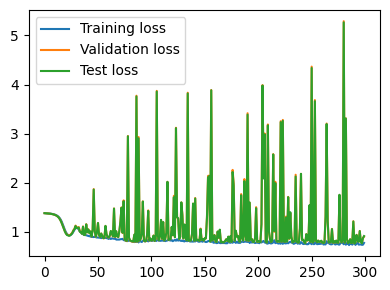

In [29]:
fig, ax = plt.subplots(1,1, figsize=(4,3))
ax.plot(train_losses, label='Training loss')
ax.plot(val_losses, label='Validation loss')
ax.plot(test_losses, label='Test loss')
ax.legend()
plt.tight_layout()
plt.savefig(r'..\..\..\figures\graph_classification_validation_v5\cosmx_set1\combined_loss_normalized_data_weighted_dynamic_lambda.png')

In [30]:
torch.save(model, r'..\..\..\results\graph_classification_validation_v5\cosmx_set1\model_normalized_data_weighted_dynamic_lambda.pth')

# evalulation of batch and label prediction

In [31]:
from sklearn.metrics import confusion_matrix

In [32]:
model.eval()
true_labels = []
pred_labels = []
true_batch = []
pred_batch = []

# Iterate over the test_loader
with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        label_out, batch_out = model(data.x, data.edge_index, data.batch)
        _, pred = torch.max(label_out, dim=1)
        _, batch = torch.max(batch_out, dim=1)
        true_labels.extend(data.label.cpu().numpy())
        pred_labels.extend(pred.cpu().numpy())
        true_batch.extend(data.source_label.cpu().numpy())
        pred_batch.extend(batch.cpu().numpy())

# Compute the confusion matrix
cm = confusion_matrix(true_labels, pred_labels)
cm_batch = confusion_matrix(true_batch, pred_batch)

In [33]:
cm

array([[1797,  434],
       [  33, 4992]])

In [34]:
cm_batch

array([[6608,  136],
       [ 470,   42]])

In [35]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from matplotlib import rc_context

In [36]:
pred_probs = []
batch_probs = []

with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        pred_out,batch_out = model(data.x, data.edge_index, data.batch)
        pred_probs.extend(pred_out.cpu().numpy()[:,1])
        batch_probs.extend(batch_out.cpu().numpy()[:,1])
auc = roc_auc_score(true_labels, pred_probs)
auc_batch = roc_auc_score(true_batch, batch_probs)

In [37]:
auc

np.float64(0.9925046216697775)

In [38]:
auc_batch

np.float64(0.6777291620329181)

In [39]:
roc_curve_pred = roc_curve(true_labels, pred_probs)
roc_curve_batch = roc_curve(true_batch, batch_probs)

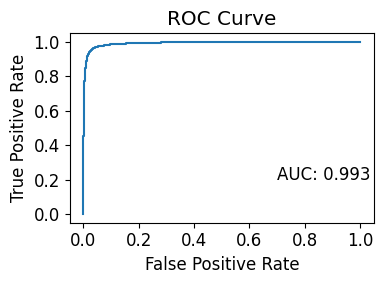

In [40]:
with rc_context({'font.size':12}):
    fig, ax = plt.subplots(1,1,figsize=(4,3))
    ax.plot(roc_curve_pred[0], roc_curve_pred[1])
    ax.text(0.7, 0.2, f'AUC: {auc:.3f}', fontsize=12)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve')
    plt.tight_layout()
    plt.savefig(r'..\..\..\figures\graph_classification_validation_v5\cosmx_set1\roc_curve_pred_normalized_data_weighted_dynamic_lambda.png')

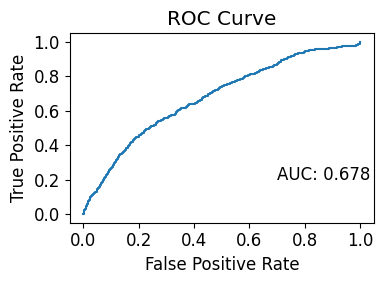

In [41]:
with rc_context({'font.size':12}):
    fig, ax = plt.subplots(1,1,figsize=(4,3))
    ax.plot(roc_curve_batch[0], roc_curve_batch[1])
    ax.text(0.7, 0.2, f'AUC: {auc_batch:.3f}', fontsize=12)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve')
    plt.tight_layout()
    plt.savefig(r'..\..\..\figures\graph_classification_validation_v5\cosmx_set1\roc_curve_batch_normalized_data_weighted_dynamic_lambda.png')

# Embedding

In [42]:
# Pooling of all graphs and save pooled features for downstream analysis
model.eval()
pooled_features = []

data = data_83a + data_83b + data_84a + data_84b + data_174c + data_174d + data_7202c + data_7202d + cosmx_data_83 + cosmx_data_84 + cosmx_data_72021 + cosmx_data_1741
data_loader = DataLoader(data, batch_size=256, shuffle=False)

with torch.no_grad():
    for data in data_loader:
        data = data.to(device)
        out = model.encoder(data.x, data.edge_index)
        # out = model.pooling(out, data.edge_index, data.batch)
        out1 = pool.global_mean_pool(out, data.batch)
        out2 = pool.global_max_pool(out, data.batch)
        out = torch.cat([out1, out2], dim=1)

        pooled_features.append(out.cpu().numpy())

d:\Users\zfang38\Anaconda3\envs\torchEnv3\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


In [43]:
with open(r'..\..\..\results\graph_classification_validation_v5\cosmx_set1\pooled_features_normalized_data_weighted_dynamic_lambda.pkl', 'wb') as f:
    pickle.dump(pooled_features, f)

In [44]:
slices = ['Xenium_83a']*len(data_83a) + ['Xenium_83b']*len(data_83b)+\
         ['Xenium_84a']*len(data_84a) + ['Xenium_84b']*len(data_84b)+\
         ['Xenium_174c']*len(data_174c) + ['Xenium_174d']*len(data_174d)+\
         ['Xenium_7202c']*len(data_7202c) + ['Xenium_7202d']*len(data_7202d)+\
         ['Cosmx_83']*len(cosmx_data_83) + ['Cosmx_84']*len(cosmx_data_84)+\
         ['Cosmx_72021']*len(cosmx_data_72021)+\
         ['Cosmx_1741']*len(cosmx_data_1741)

In [45]:
with open(r'..\..\..\results\graph_classification_validation_v5\cosmx_set1\tissue_id.pkl', 'wb') as f:
    pickle.dump(slices, f)

In [46]:
labels = ['SSA+']*(len(data_83a)+len(data_83b)+len(data_84a)+len(data_84b)) +\
         ['SSA-']*(len(data_174c)+len(data_174d)+len(data_7202c)+len(data_7202d)) +\
         ['SSA+']*(len(cosmx_data_83)+len(cosmx_data_84)) +\
         ['SSA-']*(len(cosmx_data_72021)+len(cosmx_data_1741))

In [47]:
with open(r'..\..\..\results\graph_classification_validation_v5\cosmx_set1\pooled_labels_normalized_data.pkl', 'wb') as f:
    pickle.dump(labels, f)

In [48]:
experiments = ['Xenium'] * (len(data_83a)+len(data_83b)+len(data_84a)+len(data_84b)+len(data_174c)+len(data_174d)+len(data_7202c)+len(data_7202d)) +\
             ['Cosmx'] * (len(cosmx_data_83)+len(cosmx_data_84)+len(cosmx_data_72021)+len(cosmx_data_1741))

In [49]:
with open(r'..\..\..\results\graph_classification_validation_v5\cosmx_set1\pooled_experiments_normalized_data.pkl', 'wb') as f:
    pickle.dump(experiments, f)

# Train, no dann

In [50]:
from torch.nn import CrossEntropyLoss
from torch.optim import Adam, SGD

In [51]:
model = ClassificationSimplifiedPooling([260, [200], 120, [3]], [720, [200, 100], 2])

In [52]:
model.to(device)

ClassificationSimplifiedPooling(
  (encoder): GATEncoder(
    (conv1): GATConv(260, 200, heads=3)
    (convs): ModuleList()
    (conv_out): GATConv(600, 120, heads=3)
  )
  (classifier): Classifier(
    (fc1): Linear(in_features=720, out_features=200, bias=True)
    (fcs): ModuleList(
      (0): Linear(in_features=200, out_features=100, bias=True)
    )
    (out): Linear(in_features=100, out_features=2, bias=True)
  )
)

In [53]:
n_ssa_pos = np.sum(np.array(train_label) == 'SSA+')
n_ssa_neg = np.sum(np.array(train_label) == 'SSA-')
labels_weights = torch.tensor([1.0 / n_ssa_neg, 1.0 / n_ssa_pos], dtype=torch.float32)
labels_weights = labels_weights / labels_weights.sum()

source_train = []
for item in train_data:
    source_train.append(item.source_label)
n_xenium = np.sum(np.array(source_train) == 0)
n_cosmx = np.sum(np.array(source_train) == 1)
source_weights = torch.tensor([1.0 / n_xenium, 1.0 / n_cosmx], dtype=torch.float32)
source_weights = source_weights / source_weights.sum()

In [54]:
optimizer = SGD(model.parameters(), lr=0.01)
criterion = CrossEntropyLoss(labels_weights.to(device))
# batch_criterion = CrossEntropyLoss(source_weights.to(device))
# Move the weights to the CPU for troubleshooting
# criterion = CrossEntropyLoss(torch.tensor([3332/(4404-3332), 1]).to('cpu'))

In [55]:
def train(loader):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        if data.label.shape[0] != out.shape[0]:
            min_size = min(out.shape[0], data.label.shape[0])
            out = out[:min_size]
            data.label = data.label[:min_size]
        loss = criterion(out, data.label)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)

def val(loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index, data.batch)

            # Ensure label shape matches output
            if data.label.shape[0] != out.shape[0]:
                min_size = min(out.shape[0], data.label.shape[0])
                out = out[:min_size]
                data.label = data.label[:min_size]

            loss = criterion(out, data.label)
            total_loss += loss.item() * data.num_graphs

    return total_loss / len(loader.dataset)


In [56]:
epochs = 500

In [57]:
train_losses = []
val_losses = []
test_losses = []

for epoch in range(epochs):
    train_loss = train(train_loader)
    val_loss = val(val_loader)
    test_loss = val(test_loader)
    print(f'Epoch: {epoch}, Train Loss: {train_loss}, Val Loss: {val_loss}, Test Loss: {test_loss}')
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    test_losses.append(test_loss)

d:\Users\zfang38\Anaconda3\envs\torchEnv3\lib\site-packages\torch_geometric\warnings.py:11: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(message)


Epoch: 0, Train Loss: 0.6943767328495654, Val Loss: 0.6930717225160211, Test Loss: 0.6928580622163076
Epoch: 1, Train Loss: 0.6923161834649538, Val Loss: 0.6915191522061948, Test Loss: 0.6914130411179615
Epoch: 2, Train Loss: 0.6910549814745445, Val Loss: 0.6904751866542413, Test Loss: 0.6904109027709036
Epoch: 3, Train Loss: 0.6900489337713231, Val Loss: 0.6894354284179367, Test Loss: 0.6893903594032801
Epoch: 4, Train Loss: 0.688970399746368, Val Loss: 0.6882590306207774, Test Loss: 0.6882217207054845
Epoch: 5, Train Loss: 0.6877256873829897, Val Loss: 0.6868903904270091, Test Loss: 0.6868726814857786
Epoch: 6, Train Loss: 0.6862500884848958, Val Loss: 0.6852890800230261, Test Loss: 0.6852369652167702
Epoch: 7, Train Loss: 0.6844644058087545, Val Loss: 0.6831676002044993, Test Loss: 0.6831443196094812
Epoch: 8, Train Loss: 0.682090581764223, Val Loss: 0.6804457470189285, Test Loss: 0.6804346728745474
Epoch: 9, Train Loss: 0.6790383678563786, Val Loss: 0.6769112757285819, Test Loss: 0

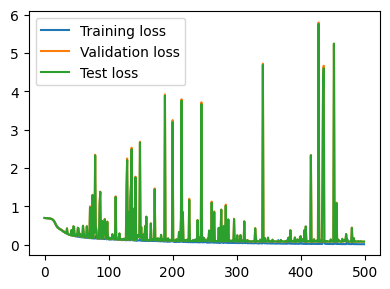

In [58]:
fig, ax = plt.subplots(1,1, figsize=(4,3))
ax.plot(train_losses, label='Training loss')
ax.plot(val_losses, label='Validation loss')
ax.plot(test_losses, label='Test loss')
ax.legend()
plt.tight_layout()
plt.savefig(r'..\..\..\figures\graph_classification_validation_v5\cosmx_set1\combined_loss_normalized_data_no_dann.png')

In [59]:
torch.save(model, r'..\..\..\results\graph_classification_validation_v5\cosmx_set1\model_normalized_data_no_dann.pth')

# evalulation of batch and label prediction

In [60]:
from sklearn.metrics import confusion_matrix

In [61]:
model.eval()
true_labels = []
pred_labels = []
true_batch = []
pred_batch = []

# Iterate over the test_loader
with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        label_out = model(data.x, data.edge_index, data.batch)
        _, pred = torch.max(label_out, dim=1)
        # _, batch = torch.max(batch_out, dim=1)
        true_labels.extend(data.label.cpu().numpy())
        pred_labels.extend(pred.cpu().numpy())
        # true_batch.extend(data.source_label.cpu().numpy())
        # pred_batch.extend(batch.cpu().numpy())

# Compute the confusion matrix
cm = confusion_matrix(true_labels, pred_labels)
# cm_batch = confusion_matrix(true_batch, pred_batch)

In [62]:
cm

array([[2179,   52],
       [ 134, 4891]])

In [63]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from matplotlib import rc_context

In [64]:
pred_probs = []
# batch_probs = []

with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        pred_out = model(data.x, data.edge_index, data.batch)
        pred_probs.extend(pred_out.cpu().numpy()[:,1])
        # batch_probs.extend(batch_out.cpu().numpy()[:,1])
auc = roc_auc_score(true_labels, pred_probs)
# auc_batch = roc_auc_score(true_batch, batch_probs)

In [65]:
auc

np.float64(0.9964067604603606)

In [66]:
roc_curve_pred = roc_curve(true_labels, pred_probs)
# roc_curve_batch = roc_curve(true_batch, batch_probs)

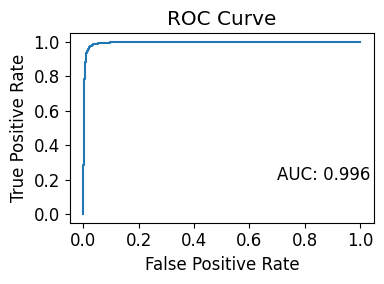

In [67]:
with rc_context({'font.size':12}):
    fig, ax = plt.subplots(1,1,figsize=(4,3))
    ax.plot(roc_curve_pred[0], roc_curve_pred[1])
    ax.text(0.7, 0.2, f'AUC: {auc:.3f}', fontsize=12)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve')
    plt.tight_layout()
    plt.savefig(r'..\..\..\figures\graph_classification_validation_v5\cosmx_set1\roc_curve_pred_normalized_data_no_dann.png')

In [68]:
# with rc_context({'font.size':12}):
#     fig, ax = plt.subplots(1,1,figsize=(4,3))
#     ax.plot(roc_curve_batch[0], roc_curve_batch[1])
#     ax.text(0.7, 0.2, f'AUC: {auc_batch:.3f}', fontsize=12)
#     ax.set_xlabel('False Positive Rate')
#     ax.set_ylabel('True Positive Rate')
#     ax.set_title(f'ROC Curve')
#     plt.tight_layout()
#     plt.savefig(r'..\..\figures\graph_classification_v4\dann\roc_curve_batch_normalized_data_weighted_dynamic_lambda.png')

# embedding

In [69]:
# Pooling of all graphs and save pooled features for downstream analysis
model.eval()
pooled_features = []

data = data_83a + data_83b + data_84a + data_84b + data_174c + data_174d + data_7202c + data_7202d + cosmx_data_83 + cosmx_data_84 + cosmx_data_72021 + cosmx_data_1741
data_loader = DataLoader(data, batch_size=256, shuffle=False)

with torch.no_grad():
    for data in data_loader:
        data = data.to(device)
        out = model.encoder(data.x, data.edge_index)
        # out = model.pooling(out, data.edge_index, data.batch)
        out1 = pool.global_mean_pool(out, data.batch)
        out2 = pool.global_max_pool(out, data.batch)
        out = torch.cat([out1, out2], dim=1)

        pooled_features.append(out.cpu().numpy())

d:\Users\zfang38\Anaconda3\envs\torchEnv3\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


In [70]:
with open(r'..\..\..\results\graph_classification_validation_v5\cosmx_set1\pooled_features_normalized_data_no_dann.pkl', 'wb') as f:
    pickle.dump(pooled_features, f)

In [71]:
slices = ['Xenium_83a']*len(data_83a) + ['Xenium_83b']*len(data_83b)+\
         ['Xenium_84a']*len(data_84a) + ['Xenium_84b']*len(data_84b)+\
         ['Xenium_174c']*len(data_174c) + ['Xenium_174d']*len(data_174d)+\
         ['Xenium_7202c']*len(data_7202c) + ['Xenium_7202d']*len(data_7202d)+\
         ['Cosmx_83']*len(cosmx_data_83) + ['Cosmx_84']*len(cosmx_data_84)+\
         ['Cosmx_72021']*len(cosmx_data_72021)+\
         ['Cosmx_1741']*len(cosmx_data_1741)

In [72]:
with open(r'..\..\..\results\graph_classification_validation_v5\cosmx_set1\tissue_id_no_dann.pkl', 'wb') as f:
    pickle.dump(slices, f)

In [73]:
labels = ['SSA+']*(len(data_83a)+len(data_83b)+len(data_84a)+len(data_84b)) +\
         ['SSA-']*(len(data_174c)+len(data_174d)+len(data_7202c)+len(data_7202d)) +\
         ['SSA+']*(len(cosmx_data_83)+len(cosmx_data_84)) +\
         ['SSA-']*(len(cosmx_data_72021)+len(cosmx_data_1741))

In [74]:
with open(r'..\..\..\results\graph_classification_validation_v5\cosmx_set1\pooled_labels_normalized_data_no_dann.pkl', 'wb') as f:
    pickle.dump(labels, f)

In [75]:
experiments = ['Xenium'] * (len(data_83a)+len(data_83b)+len(data_84a)+len(data_84b)+len(data_174c)+len(data_174d)+len(data_7202c)+len(data_7202d)) +\
             ['Cosmx'] * (len(cosmx_data_83)+len(cosmx_data_84)+len(cosmx_data_72021)+len(cosmx_data_1741))

In [76]:
with open(r'..\..\..\results\graph_classification_validation_v5\cosmx_set1\pooled_experiments_normalized_data_no_dann.pkl', 'wb') as f:
    pickle.dump(experiments, f)